# v2 — CAFEIN-aligned implementation

This notebook is a parallel **v2** of the original proof-of-concept. The original notebook is intentionally left unchanged.

**Goal:** reproduce the same research question while following the CAFEIN workflow documented in the environmental-exposure guide as closely as the public API allows.

Important distinction:
- CAFEIN directly defines route/network exposure through `StreetNetwork`, `Exposure`, and `DetailedItineraries`.
- Residential point exposure and OD destination-weighted exposure are not defined as native CAFEIN routing operations in the documentation supplied for this comparison. Those parts therefore remain analytical extensions around the CAFEIN sample data and are labelled as such.

All v2 outputs are written under `../outputs/v2/` so they can be compared with v1 without overwriting anything.

## 1. Imports and CAFEIN-style PM₂.₅ loading

This follows the documentation pattern: load the FMI-ENFUSER raster with `rioxarray`, identify the PM₂.₅ band by name, and keep the original raster for analysis.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rioxarray
import rasterio

import cafein.sampledata.helsinki as helsinki

OUTPUT_DIR = Path("../outputs/v2/01_residential_pm25_exposure")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

air_quality = rioxarray.open_rasterio(helsinki.air_quality, masked=True)
air_quality_bands = list(air_quality.attrs["long_name"])
pm25_band = air_quality_bands.index("PM25Concentration [ug/m3]") + 1
pm25 = air_quality.sel(band=pm25_band)

print("PM2.5 band:", pm25_band)
print("Raster cells:", f"{pm25.size:,}")
print("Raster CRS:", pm25.rio.crs)

PM2.5 band: 5
Raster cells: 5,309,358
Raster CRS: EPSG:4326


## 2. Map the environmental layer as CAFEIN does

For display only, the documentation reprojects the PM₂.₅ raster to a 100 m grid. The original raster remains the analytical source.

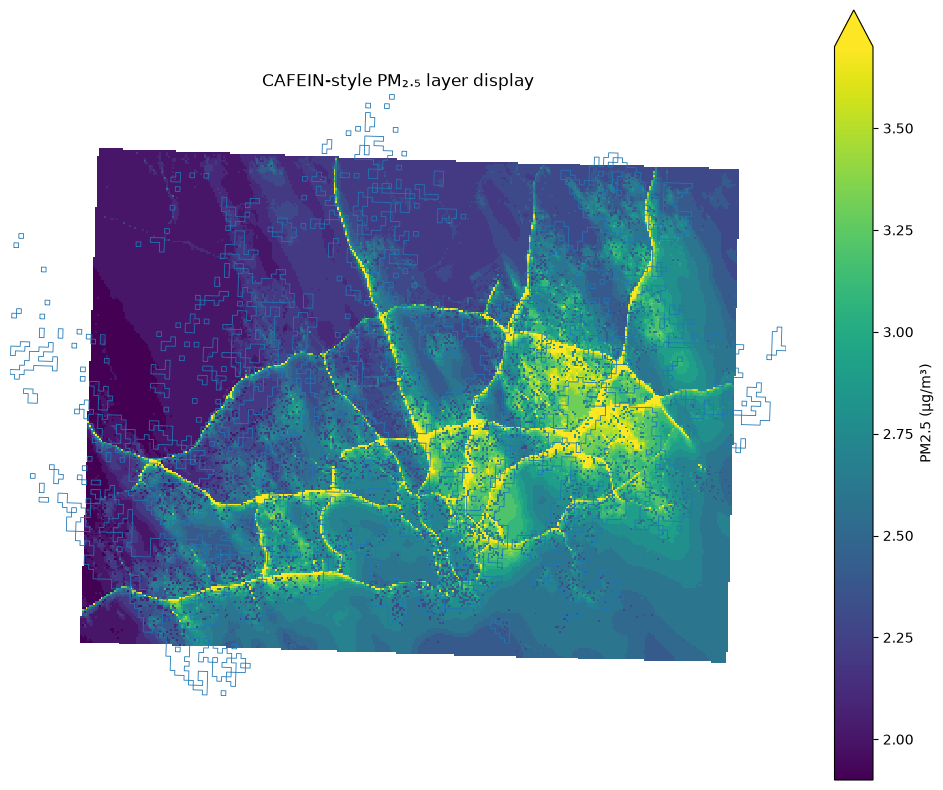

In [2]:
population_grid = gpd.read_file(helsinki.population_grid)
map_crs = population_grid.crs
region_outline = population_grid.dissolve()

pm25_for_map = pm25.rio.reproject(map_crs, resolution=100)
min_x, min_y, max_x, max_y = population_grid.total_bounds

fig, ax = plt.subplots(figsize=(10, 8))
pm25_for_map.plot(ax=ax, robust=True, cbar_kwargs={"label": "PM2.5 (µg/m³)"})
region_outline.boundary.plot(ax=ax, linewidth=0.6)
ax.set_xlim(min_x, max_x); ax.set_ylim(min_y, max_y)
ax.set_title("CAFEIN-style PM₂.₅ layer display")
ax.set_axis_off()
plt.tight_layout()
plt.show()

## 3. Residential exposure extension

CAFEIN's supplied exposure guide does **not** define residential centroid exposure as a native `Exposure` operation. To preserve the Stage 01 research question, we retain the v1 residential sampling as a clearly labelled extension. This means Stage 01 is a data-loading/mapping comparison, not a routing-engine comparison.

In [3]:
pop_pts = population_grid.copy()
pop_pts["geometry"] = pop_pts.geometry.centroid

with rasterio.open(helsinki.air_quality) as src:
    pop_pts_raster = pop_pts.to_crs(src.crs)
    coords = [(p.x, p.y) for p in pop_pts_raster.geometry]
    vals = [v[0] for v in src.sample(coords, indexes=pm25_band, masked=True)]

clean=[]
for v in vals:
    if np.ma.is_masked(v): clean.append(np.nan)
    else:
        x=float(v)
        clean.append(x if x>0 else np.nan)
pop_pts["pm25_v2"] = clean

print(pop_pts["pm25_v2"].describe())

count    5552.000000
mean        2.696019
std         0.472467
min         1.900000
25%         2.400000
50%         2.600000
75%         2.900000
max         5.300000
Name: pm25_v2, dtype: float64


In [4]:
pop_pts[["pm25_v2", "geometry"]].to_file(
    OUTPUT_DIR / "residential_pm25_v2.gpkg", layer="residential_pm25", driver="GPKG"
)
pop_pts.drop(columns="geometry").to_csv(OUTPUT_DIR / "residential_pm25_v2.csv", index=False)
print("Saved:", OUTPUT_DIR)

Saved: ../outputs/v2/01_residential_pm25_exposure


## 4. v1 ↔ v2 comparison

If you export the v1 residential results to CSV, place them in `../outputs/01_residential_pm25_exposure/residential_pm25_v1.csv`. The cell below will compare distributions when that file exists.

In [5]:
v1_path = Path("../outputs/01_residential_pm25_exposure/residential_pm25_v1.csv")
if v1_path.exists():
    v1 = pd.read_csv(v1_path)
    print("v1 columns:", v1.columns.tolist())
    print("v2 mean:", pop_pts["pm25_v2"].mean())
else:
    print("No v1 CSV found; v2 output has been saved for later comparison.")

No v1 CSV found; v2 output has been saved for later comparison.
